# NB13b — Constellation Centroid Map

**Complementary to NB13a:** NB13a (NB7-aligned) shows the distribution structure at each layer (Fig 1b: where does over-refusal sit in the combined UMAP? Fig 1c: how big is the behavioral gap vs. the inter-task gap?). NB13b shows the **trajectory** — how centroids move through layers in a consistent coordinate system.

**Key question:** Do the dashed over-refusal centroid paths (Fig 1) closely track the solid task centroid paths, or do they diverge into a separate region? If they track closely → within-cluster narrative confirmed at centroid level.

## Three Figures
- **Figure 1 — Centroid Galaxy:** PCA of task centroid vectors across **all 32 layers**. Solid = task centroid, dashed = over-refusal centroid (lighter, same task colour). Shared PCA space — cross-layer positions are genuinely comparable.
- **Figure 2 — Behavior Trajectories:** For the 3 tasks with over-refusal data (rephrase, sentiment, translate): target-behavior centroid vs. over-refusal centroid paths across 8 key layers in a shared L12-anchored UMAP space. Reports final gap at L28.
- **Figure 3 — Honest L12 Snapshot:** Full raw scatter of all 270 samples at peak-constellation layer L12. Color = task, shape = behavior marker. Centroid stars overlaid. No filtering or aggregation.

**Compute:** ~3 min | Embedding-only, no model inference.

In [10]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from matplotlib.patches import FancyArrowPatch, Patch
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA as PCA_sk
from sklearn.metrics import silhouette_score
import warnings, os, json

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.size':        12,
    'axes.titlesize':   13,
    'axes.labelsize':   12,
    'legend.fontsize':  10,
    'xtick.labelsize':  10,
    'ytick.labelsize':  10,
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.grid':        True,
    'grid.alpha':       0.25,
    'font.family':      'serif',
})

TASK_COLORS = {
    'sentiment_analysis': '#E74C3C',
    'translate':          '#3498DB',
    'rephrase':           '#F39C12',
    'rag_qa':             '#27AE60',
    'cryptanalysis':      '#9B59B6',
}

print('✓ Setup complete (ACL 2-col, PCA-based, no umap required)')


✓ Setup complete (ACL 2-col, PCA-based, no umap required)


In [11]:
# ── Colab: mount Drive and copy embeddings ────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')
os.makedirs('./embeddings', exist_ok=True)
!cp -a "/content/drive/MyDrive/embeddings/overalign_eval/llama/." ./embeddings/.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
cp: cannot open '/content/drive/MyDrive/embeddings/overalign_eval/llama/./overalign_eval_Meta-Llama-3.1-8B-Instruct_20250714_082134.gsheet' for reading: Operation not supported


In [12]:
# ── Data loading ──────────────────────────────────────────────────────────────
embeddings_dir = './embeddings/'
csv_df = pd.read_csv(os.path.join(embeddings_dir,
             sorted([f for f in os.listdir(embeddings_dir) if f.endswith('.csv')])[-1]))

torch_data           = torch.load(csv_df['torch_path'].iloc[0])
texts                = torch_data['texts']
text_type_labels     = np.array(torch_data['text_type_labels'])
intended_task_labels = np.array(torch_data['intended_task_labels'])
response_labels      = csv_df['llm_evaluation'].values
refusal_labels       = csv_df['refusal_class'].values

def to_np(d):
    return {
        k: (v.float().numpy().astype(np.float32) if isinstance(v, torch.Tensor)
            else np.array([e.float().numpy().astype(np.float32) for e in v]))
        for k, v in d.items()
    }

embeddings_np = to_np(torch_data['embeddings'])

ALL_TASKS   = sorted(np.unique(intended_task_labels).tolist())
N_SAMPLES   = len(texts)
LAYER_NAMES = [f'layer_{l}_input_norm' for l in range(32)
               if f'layer_{l}_input_norm' in embeddings_np]
N_LAYERS    = len(LAYER_NAMES)

print(f'{N_SAMPLES} samples | {N_LAYERS} layers | {len(ALL_TASKS)} tasks')
print(f'Tasks: {ALL_TASKS}')

270 samples | 31 layers | 5 tasks
Tasks: ['cryptanalysis', 'rag_qa', 'rephrase', 'sentiment_analysis', 'translate']


In [13]:
# ── Canonical behavioral masks (two-mask design from NB8) ─────
BENIGN_TASKS  = ['sentiment_analysis', 'translate', 'cryptanalysis', 'rag_qa']
refusing_mask = (refusal_labels == 'direct_refusal') | (refusal_labels == 'indirect_refusal')
answered_mask = refusal_labels == 'direct_answer'
harmful_mask  = text_type_labels == 'harmful_instruction'
benign_mask   = np.isin(intended_task_labels, BENIGN_TASKS)

OVER_REFUSAL_MASK      = benign_mask  & refusing_mask         # n≈48
REFUSED_HARMFUL_MASK   = harmful_mask & refusing_mask         # n≈25
HARMLESS_ANSWERED_MASK = benign_mask  & answered_mask         # n≈157 (wide, for viz)
DIRECTION_HA_MASK      = (text_type_labels == 'benign_instruction') & answered_mask  # ~30 (strict)

beh_labels = np.full(len(texts), 'other', dtype=object)
beh_labels[REFUSED_HARMFUL_MASK]   = 'refused_harmful'
beh_labels[OVER_REFUSAL_MASK]      = 'over_refusal'
beh_labels[HARMLESS_ANSWERED_MASK] = 'harmless_answered'

TASKS_WITH_OR = [t for t in ALL_TASKS
                 if ((intended_task_labels == t) & OVER_REFUSAL_MASK).sum() >= 3]

try:
    with open('arditi_artefacts/direction_metadata.json') as f:
        BEST_LAYER = json.load(f)['best_layer']
except Exception:
    BEST_LAYER = 'layer_12_input_norm'

print('=== MASK DISTRIBUTION ===')
print(f'  Over-refusal (OR):         {OVER_REFUSAL_MASK.sum():>4d}')
print(f'  Refused-harmful (RH):      {REFUSED_HARMFUL_MASK.sum():>4d}')
print(f'  Harmless-answered (wide):  {HARMLESS_ANSWERED_MASK.sum():>4d}')
print(f'  Direction-HA (strict):     {DIRECTION_HA_MASK.sum():>4d}')
print(f'  Tasks with OR ≥3:          {TASKS_WITH_OR}')
print(f'  Best layer (from NB8):     {BEST_LAYER}')
print()
for task in ALL_TASKS:
    tm = intended_task_labels == task
    n_or = (tm & OVER_REFUSAL_MASK).sum()
    if n_or > 0:
        print(f'  {task:<22}: OR={n_or}  HA={( tm & HARMLESS_ANSWERED_MASK).sum()}')


=== MASK DISTRIBUTION ===
  Over-refusal (OR):           48
  Refused-harmful (RH):        25
  Harmless-answered (wide):   157
  Direction-HA (strict):       30
  Tasks with OR ≥3:          ['sentiment_analysis', 'translate']
  Best layer (from NB8):     layer_12_input_norm

  sentiment_analysis    : OR=20  HA=35
  translate             : OR=28  HA=32


In [14]:
# ── PRE-COMPUTATION (PCA-based, no UMAP) ─────────────────────
print('Pre-computing centroid trajectories...')

# ── Anchor: PCA fitted at BEST_LAYER (L12) ───────────────────
emb_anchor  = embeddings_np[BEST_LAYER]
pca_anchor  = PCA_sk(n_components=2, random_state=42)
emb2d_anchor = pca_anchor.fit_transform(emb_anchor)  # (N, 2)

# ── Project all layers into L12 PCA space ────────────────────
# Consistent reference frame for trajectory visualisation
layer_proj = {lname: pca_anchor.transform(embeddings_np[lname]) for lname in LAYER_NAMES}

# ── Task centroids in anchor PCA space ───────────────────────
task_cent_2d = {}   # (task, lname) -> (2,)
for lname in LAYER_NAMES:
    for task in ALL_TASKS:
        mask = intended_task_labels == task
        task_cent_2d[(task, lname)] = layer_proj[lname][mask].mean(0)

# ── OR and HA centroids per task at each layer ────────────────
or_cent_2d = {}   # (task, lname) -> (2,)
ha_cent_2d = {}   # (task, lname) -> (2,)
for lname in LAYER_NAMES:
    proj = layer_proj[lname]
    for task in ALL_TASKS:
        or_m = (intended_task_labels == task) & OVER_REFUSAL_MASK
        ha_m = (intended_task_labels == task) & HARMLESS_ANSWERED_MASK
        if or_m.sum() >= 2:
            or_cent_2d[(task, lname)] = proj[or_m].mean(0)
        if ha_m.sum() >= 2:
            ha_cent_2d[(task, lname)] = proj[ha_m].mean(0)

# ── PCA of centroid space: stack all task centroids ───────────
# Shape: (N_TASKS * N_LAYERS, D) for PCA → shows galaxy trajectory
cent_stack = np.stack([
    embeddings_np[lname][intended_task_labels == task].mean(0)
    for task in ALL_TASKS
    for lname in LAYER_NAMES
])
pca_cent   = PCA_sk(n_components=2, random_state=42)
cent_2d    = pca_cent.fit_transform(cent_stack)

cent_2d_by_task = {}   # task -> (N_LAYERS, 2)
for ti, task in enumerate(ALL_TASKS):
    cent_2d_by_task[task] = cent_2d[ti*N_LAYERS:(ti+1)*N_LAYERS]

# Global OR and HA centroid trajectories in centroid PCA space
or_cent_global_2d = pca_cent.transform(
    np.stack([embeddings_np[l][OVER_REFUSAL_MASK].mean(0) for l in LAYER_NAMES]))
ha_cent_global_2d = pca_cent.transform(
    np.stack([embeddings_np[l][HARMLESS_ANSWERED_MASK].mean(0) for l in LAYER_NAMES]))

# ── Load Arditi directions ────────────────────────────────────
arditi_dirs = {}
try:
    raw = torch.load('arditi_artefacts/candidate_directions.pt')
    for k, v in raw.items():
        d = v.numpy().astype(np.float32) if isinstance(v, torch.Tensor) else np.array(v, dtype=np.float32)
        arditi_dirs[k] = d / (np.linalg.norm(d) + 1e-8)
    print(f'Arditi directions loaded: {len(arditi_dirs)} layers')
except Exception as e:
    print(f'Warning: Arditi directions not available ({e})')

var_a = pca_anchor.explained_variance_ratio_
var_c = pca_cent.explained_variance_ratio_
print(f'Anchor PCA (L{int(BEST_LAYER.split("_")[1]):02d}): PC1={var_a[0]:.1%} PC2={var_a[1]:.1%}')
print(f'Centroid PCA: PC1={var_c[0]:.1%} PC2={var_c[1]:.1%}')
print('Pre-computation complete.')


Pre-computing centroid trajectories...
Anchor PCA (L12): PC1=40.5% PC2=12.1%
Centroid PCA: PC1=28.4% PC2=11.2%
Pre-computation complete.


---
## Figure 1 — Task Centroid Galaxy

**What this is:** PCA of all task centroid vectors across **all layers (L00–L31)**. Each of the 5 tasks traces a path from its L00 centroid (★) through every layer. Tasks with over-refusal samples also show a **dashed trajectory** of the over-refusal centroid (same task color, lighter) so you can see where target and refusal representations diverge inside each task's path.

**How to read it:** Stars = layer 0 (starting position). Solid lines = task centroid (all samples). Dashed lines = over-refusal centroid (refused benign samples only). Layer numbers annotated every 8 layers (L00, L08, L16, L24, L31). Arrows every 4 layers.

**Why PCA (not UMAP):** With centroids as the unit of analysis, PCA is well-defined and produces a meaningful global linear projection regardless of sample count.

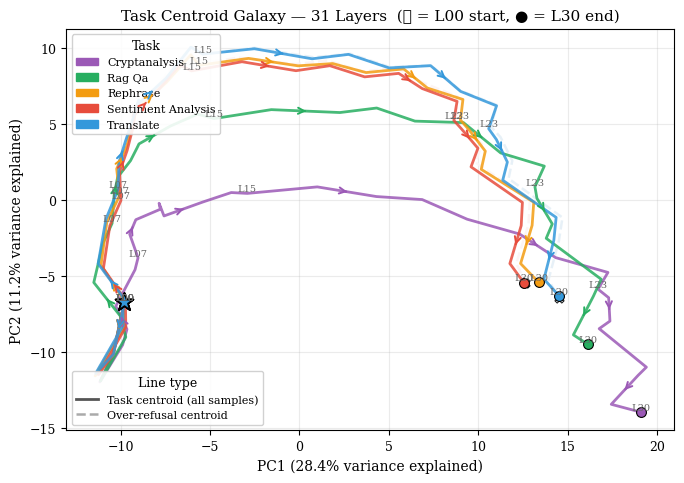


=== FIGURE DATA: CENTROID GALAXY ===
pca_cent: PC1=28.4%, PC2=11.2%  (fitted on 155 centroid vectors)
Tasks with OR trajectory: ['sentiment_analysis', 'translate']

Task centroid displacement L00→L30 (pca_cent 2D space):
  cryptanalysis         : 29.757
  rag_qa                : 26.052
  rephrase              : 23.203
  sentiment_analysis    : 22.374
  translate             : 24.321

OR vs task centroid gap at L30 (pca_cent 2D space):
  sentiment_analysis    : 0.080
  translate             : 0.131

Saved: fig_nb13b_galaxy.pdf


In [15]:
# ── FIGURE 1 — Task Centroid Galaxy (ALL layers, PCA of centroid space) ───────
import colorsys

def lighten_hex(hex_color, factor=0.40):
    hex_color = hex_color.lstrip('#')
    r, g, b = [int(hex_color[i:i+2], 16)/255.0 for i in (0, 2, 4)]
    h, l, s = colorsys.rgb_to_hls(r, g, b)
    l = min(1.0, l + factor); s = max(0.0, s - 0.20)
    r2, g2, b2 = colorsys.hls_to_rgb(h, l, s)
    return '#{:02x}{:02x}{:02x}'.format(int(r2*255), int(g2*255), int(b2*255))

# Per-task OR centroid trajectories in pca_cent space
or_cent_galaxy = {}
for task in TASKS_WITH_OR:
    stack = []
    for lname in LAYER_NAMES:
        or_m = (intended_task_labels == task) & OVER_REFUSAL_MASK
        c = embeddings_np[lname][or_m].mean(0) if or_m.sum() >= 2 \
            else embeddings_np[lname][intended_task_labels == task].mean(0)
        stack.append(c)
    or_cent_galaxy[task] = pca_cent.transform(np.stack(stack))  # (N_LAYERS, 2)

var_c = pca_cent.explained_variance_ratio_
ANNOT_IDX = sorted({0, N_LAYERS//4, N_LAYERS//2, 3*N_LAYERS//4, N_LAYERS-1})

fig, ax = plt.subplots(figsize=(7.0, 5.0))

for task in ALL_TASKS:
    color = TASK_COLORS[task]
    traj  = cent_2d_by_task[task]          # (N_LAYERS, 2)

    ax.plot(traj[:, 0], traj[:, 1], color=color, lw=2.0, alpha=0.85, zorder=5,
            solid_capstyle='round', solid_joinstyle='round')

    # Direction arrows every 4 layers
    for j in range(0, N_LAYERS - 1, 4):
        mid = (traj[j] + traj[j+1]) / 2
        d   = traj[j+1] - traj[j]
        if np.linalg.norm(d) < 1e-8: continue
        ax.annotate('', xy=mid + d*0.01, xytext=mid - d*0.01,
                    arrowprops=dict(arrowstyle='->', color=color, lw=1.4,
                                   mutation_scale=11), zorder=6)

    # Start star, end dot
    ax.scatter(*traj[0],  c=color, s=180, marker='*', zorder=12,
               edgecolors='black', linewidths=1.2)
    ax.scatter(*traj[-1], c=color, s=50,  marker='o', zorder=10,
               edgecolors='black', linewidths=0.8)

    # Annotate key layers
    for li in ANNOT_IDX:
        pt  = traj[li]
        lno = int(LAYER_NAMES[li].split('_')[1])
        ax.text(pt[0], pt[1] + 0.015, f'L{lno:02d}',
                fontsize=7, ha='center', color='#666', va='bottom', zorder=13)

# OR centroid trajectories (dashed, lighter)
for task in TASKS_WITH_OR:
    color = lighten_hex(TASK_COLORS[task])
    traj  = or_cent_galaxy[task]

    ax.plot(traj[:, 0], traj[:, 1], color=color, lw=1.8, ls='--', alpha=0.88, zorder=4,
            solid_capstyle='round', solid_joinstyle='round')
    ax.scatter(*traj[0],  c=color, s=140, marker='*', zorder=11,
               edgecolors='black', linewidths=1.0)
    ax.scatter(*traj[-1], c=color, s=45,  marker='X', zorder=9,
               edgecolors='black', linewidths=0.6)

# Legend
task_handles  = [Patch(color=TASK_COLORS[t], label=t.replace('_', ' ').title()) for t in ALL_TASKS]
style_handles = [
    Line2D([0], [0], color='#555', lw=2.0, ls='-',  label='Task centroid (all samples)'),
    Line2D([0], [0], color='#aaa', lw=1.8, ls='--', label='Over-refusal centroid'),
]
leg1 = ax.legend(handles=task_handles,  loc='upper left',  fontsize=8,
                 title='Task', title_fontsize=9, framealpha=0.9)
ax.legend(handles=style_handles, loc='lower left', fontsize=8,
          title='Line type', title_fontsize=9, framealpha=0.9)
ax.add_artist(leg1)

last_lno = int(LAYER_NAMES[-1].split('_')[1])
ax.set_xlabel(f'PC1 ({var_c[0]:.1%} variance explained)', fontsize=10)
ax.set_ylabel(f'PC2 ({var_c[1]:.1%} variance explained)', fontsize=10)
ax.set_title(f'Task Centroid Galaxy — {N_LAYERS} Layers  '
             f'(★ = L00 start, ● = L{last_lno:02d} end)', fontsize=11)
ax.tick_params(labelsize=9)
plt.tight_layout()
plt.savefig('fig_nb13b_galaxy.pdf', dpi=300, bbox_inches='tight')
plt.show()

# ── FIGURE DATA ────────────────────────────────────────────────────────────────
print('\n=== FIGURE DATA: CENTROID GALAXY ===')
print(f'pca_cent: PC1={var_c[0]:.1%}, PC2={var_c[1]:.1%}  '
      f'(fitted on {len(ALL_TASKS)*N_LAYERS} centroid vectors)')
print(f'Tasks with OR trajectory: {TASKS_WITH_OR}')
print(f'\nTask centroid displacement L00→L{last_lno:02d} (pca_cent 2D space):')
for task in ALL_TASKS:
    traj = cent_2d_by_task[task]
    d    = np.linalg.norm(traj[-1] - traj[0])
    print(f'  {task:<22}: {d:.3f}')
print(f'\nOR vs task centroid gap at L{last_lno:02d} (pca_cent 2D space):')
for task in TASKS_WITH_OR:
    tc  = cent_2d_by_task[task][-1]
    oc  = or_cent_galaxy[task][-1]
    print(f'  {task:<22}: {np.linalg.norm(tc - oc):.3f}')
print('\nSaved: fig_nb13b_galaxy.pdf')


---
## Figure 2 — Within-Task Behavior Centroid Trajectories

**What this is:** For tasks with over-refusal data, we show how the **harmless-answered centroid** (HA, solid) and the **over-refusal centroid** (OR, dashed) move across 8 key layers — in a shared L12-anchored PCA space.

**How to read it:** Background = all samples at L12 (grey = rest of dataset, task-colored = this task's cloud). The gap between the two centroid paths grows through middle layers, revealing where the model's representation diverges for refused vs. answered benign samples.

**Why L12-anchored PCA:** All layers are projected into the PCA basis fitted at the peak constellation layer (L12), giving a consistent reference frame. Directions are interpretable as linear combinations of the high-dim representations.


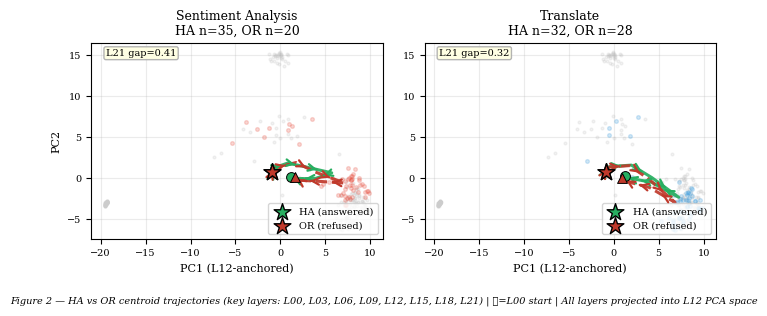


=== FIGURE DATA: BEHAVIOR TRAJECTORIES ===
Key layers: [0, 3, 6, 9, 12, 15, 18, 21]

  sentiment_analysis  (HA n=35, OR n=20):
    L00: HA=(-0.90,0.76)  OR=(-0.90,0.76)  gap=0.000
    L03: HA=(-0.73,1.29)  OR=(-0.70,1.25)  gap=0.046
    L06: HA=(0.81,1.87)  OR=(1.73,1.93)  gap=0.925
    L09: HA=(2.39,1.51)  OR=(3.86,0.78)  gap=1.637
    L12: HA=(5.71,0.68)  OR=(7.13,-0.57)  gap=1.890
    L15: HA=(3.93,0.00)  OR=(4.49,-0.37)  gap=0.669
    L18: HA=(1.63,-0.05)  OR=(2.12,-0.23)  gap=0.517
    L21: HA=(1.20,0.14)  OR=(1.60,0.18)  gap=0.409

  translate  (HA n=32, OR n=28):
    L00: HA=(-0.90,0.76)  OR=(-0.90,0.76)  gap=0.000
    L03: HA=(-0.48,1.43)  OR=(-0.53,1.38)  gap=0.073
    L06: HA=(1.97,1.62)  OR=(1.77,1.56)  gap=0.206
    L09: HA=(4.26,0.09)  OR=(3.99,-0.15)  gap=0.366
    L12: HA=(7.23,-2.30)  OR=(6.83,-2.93)  gap=0.745
    L15: HA=(4.25,-0.48)  OR=(3.98,-1.11)  gap=0.679
    L18: HA=(2.05,-0.04)  OR=(1.78,-0.48)  gap=0.517
    L21: HA=(1.22,0.26)  OR=(0.97,0.04)  gap=0.325

Sa

In [16]:
# ── FIGURE 2 — Within-Task Behavior Centroid Trajectories (L12-anchored PCA) ─
# Key layers: 8 evenly spaced across all N_LAYERS
KEY_LAYER_IDX  = list(range(0, N_LAYERS, max(1, N_LAYERS // 8)))[:8]
KEY_LNAMES     = [LAYER_NAMES[i]                 for i in KEY_LAYER_IDX]
KEY_LAYER_NUMS = [int(ln.split('_')[1])           for ln in KEY_LNAMES]

TARGET_COLOR = '#27AE60'   # green — correctly answered
OR_COLOR     = '#C0392B'   # red   — incorrectly refused

n_panels = len(TASKS_WITH_OR)
fig, axes = plt.subplots(1, n_panels, figsize=(7.0, 3.0), sharey=False)
if n_panels == 1:
    axes = [axes]

for panel_idx, (ax, task) in enumerate(zip(axes, TASKS_WITH_OR)):
    task_color = TASK_COLORS[task]
    tmask      = intended_task_labels == task

    # Background: full L12 scatter (grey = other tasks, task-color = this task)
    ax.scatter(emb2d_anchor[~tmask, 0], emb2d_anchor[~tmask, 1],
               c='#cccccc', s=4, alpha=0.25, rasterized=True, zorder=1)
    ax.scatter(emb2d_anchor[tmask, 0], emb2d_anchor[tmask, 1],
               c=task_color, s=7, alpha=0.22, rasterized=True, zorder=2)

    for (mask_key, color, ls, mshape, label_str) in [
        (HARMLESS_ANSWERED_MASK, TARGET_COLOR, '-',  'o', 'HA (answered)'),
        (OVER_REFUSAL_MASK,      OR_COLOR,     '--', '^', 'OR (refused)'),
    ]:
        per_task_mask = (intended_task_labels == task) & mask_key
        if per_task_mask.sum() < 2:
            continue

        traj = np.stack([layer_proj[ln][per_task_mask].mean(0)
                         for ln in KEY_LNAMES])  # (K, 2)

        ax.plot(traj[:, 0], traj[:, 1], color=color, lw=2.2, ls=ls,
                alpha=0.92, zorder=5, solid_capstyle='round')

        # Direction arrows between waypoints
        for j in range(len(KEY_LNAMES) - 1):
            mid = (traj[j] + traj[j+1]) / 2
            d   = traj[j+1] - traj[j]
            if np.linalg.norm(d) < 1e-8:
                continue
            ax.annotate('', xy=mid + d*0.01, xytext=mid - d*0.01,
                        arrowprops=dict(arrowstyle='->', color=color,
                                        lw=1.6, mutation_scale=12), zorder=6)

        ax.scatter(*traj[0],  c=color, s=160, marker='*', zorder=10,
                   edgecolors='black', linewidths=1.0, label=label_str)
        ax.scatter(*traj[-1], c=color, s=50,  marker=mshape, zorder=9,
                   edgecolors='black', linewidths=0.7)

    # Gap annotation at last key layer
    ha_m = (intended_task_labels == task) & HARMLESS_ANSWERED_MASK
    or_m = (intended_task_labels == task) & OVER_REFUSAL_MASK
    if ha_m.sum() >= 2 and or_m.sum() >= 2:
        ha_last = layer_proj[KEY_LNAMES[-1]][ha_m].mean(0)
        or_last = layer_proj[KEY_LNAMES[-1]][or_m].mean(0)
        gap = np.linalg.norm(ha_last - or_last)
        ax.text(0.05, 0.97, f'L{KEY_LAYER_NUMS[-1]:02d} gap={gap:.2f}',
                transform=ax.transAxes, fontsize=7, va='top',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='lightyellow',
                          alpha=0.88, edgecolor='#aaa'))

    n_ha = ha_m.sum(); n_or = or_m.sum()
    ax.set_title(f'{task.replace("_", " ").title()}\nHA n={n_ha}, OR n={n_or}', fontsize=9)
    ax.set_xlabel(f'PC1 (L{int(BEST_LAYER.split("_")[1]):02d}-anchored)', fontsize=8)
    if panel_idx == 0:
        ax.set_ylabel('PC2', fontsize=8)
    ax.legend(fontsize=7, loc='lower right', frameon=True)
    ax.tick_params(labelsize=7)

key_str = ', '.join([f'L{n:02d}' for n in KEY_LAYER_NUMS])
fig.text(0.5, -0.04,
         f'Figure 2 — HA vs OR centroid trajectories (key layers: {key_str}) | '
         f'★=L{KEY_LAYER_NUMS[0]:02d} start | All layers projected into L{int(BEST_LAYER.split("_")[1]):02d} PCA space',
         ha='center', fontsize=7, style='italic')
plt.tight_layout()
plt.savefig('fig_nb13b_trajectories.pdf', dpi=300, bbox_inches='tight')
plt.show()

# ── FIGURE DATA ────────────────────────────────────────────────────────────────
print('\n=== FIGURE DATA: BEHAVIOR TRAJECTORIES ===')
print(f'Key layers: {KEY_LAYER_NUMS}')
for task in TASKS_WITH_OR:
    ha_m = (intended_task_labels == task) & HARMLESS_ANSWERED_MASK
    or_m = (intended_task_labels == task) & OVER_REFUSAL_MASK
    print(f'\n  {task}  (HA n={ha_m.sum()}, OR n={or_m.sum()}):')
    for ln, lnum in zip(KEY_LNAMES, KEY_LAYER_NUMS):
        if ha_m.sum() < 2 or or_m.sum() < 2:
            continue
        ha_pt = layer_proj[ln][ha_m].mean(0)
        or_pt = layer_proj[ln][or_m].mean(0)
        gap   = np.linalg.norm(ha_pt - or_pt)
        print(f'    L{lnum:02d}: HA=({ha_pt[0]:.2f},{ha_pt[1]:.2f})  '
              f'OR=({or_pt[0]:.2f},{or_pt[1]:.2f})  gap={gap:.3f}')
print('\nSaved: fig_nb13b_trajectories.pdf')


---
## Figure 3 — Peak-Layer PCA Snapshot with OR Direction Arrows

**What this is:** All 270 samples projected to 2D PCA at the peak constellation layer (L12). Color = task, shape = behavioral class. Per-task **colored arrows** show the within-task OR direction (from HA centroid → OR centroid), and the **black arrow** shows the global Arditi direction projected into the same space.

**Key claim:** The colored OR arrows point in *different* task-specific directions, while the Arditi arrow points in a single fixed direction — demonstrating why a global ablation cannot selectively fix over-refusal without damaging task-specific representations. Over-refusal representations sit *inside* their task clusters, not in a separable global subspace.


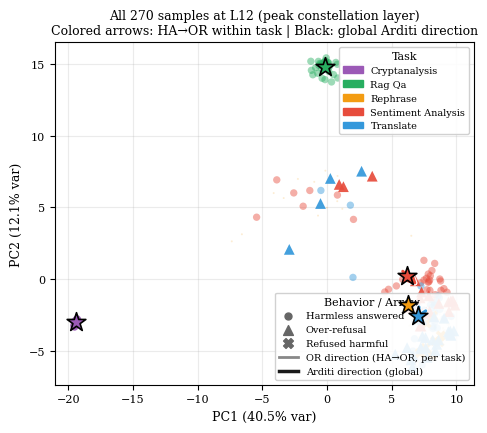


=== FIGURE DATA: L12 SNAPSHOT WITH OR ARROWS ===
BEST_LAYER: layer_12_input_norm
pca_anchor: PC1=40.5%, PC2=12.1%

OR arrow vectors (HA→OR in PCA space) at L12:
  sentiment_analysis    : HA=(5.71,0.68)  OR=(7.13,-0.57)  |arrow|=1.890  dir=(0.75,-0.66)
  translate             : HA=(7.23,-2.30)  OR=(6.83,-2.93)  |arrow|=0.745  dir=(-0.54,-0.84)

Saved: fig_nb13b_l12_snapshot.pdf


In [17]:
# ── FIGURE 3 — Peak-Layer PCA Snapshot with OR Direction Arrows ───────────────
# The key 2D visualization: OR sits INSIDE task clusters; OR directions diverge

def draw_arrow_in_pca(ax, d_unit, pca, cx, cy, scale, color, lw, zorder=10, ms=14):
    """Project a high-dim unit direction into PCA space and draw FancyArrowPatch."""
    d2 = pca.components_ @ d_unit          # (2,)
    d2 = d2 / (np.linalg.norm(d2) + 1e-8)
    x0, y0 = cx - d2[0]*scale, cy - d2[1]*scale
    x1, y1 = cx + d2[0]*scale, cy + d2[1]*scale
    arrow = FancyArrowPatch(
        (x0, y0), (x1, y1),
        arrowstyle='->', mutation_scale=ms,
        color=color, linewidth=lw, zorder=zorder, clip_on=False,
        path_effects=[pe.withStroke(linewidth=lw + 2.0, foreground='white')]
    )
    ax.add_patch(arrow)

BEH_MARKERS = {
    'harmless_answered': 'o',
    'over_refusal':      '^',
    'refused_harmful':   'X',
    'other':             '.',
}
BEH_SIZES = {'harmless_answered': 28, 'over_refusal': 60, 'refused_harmful': 55, 'other': 8}
BEH_ALPHA = {'harmless_answered': 0.45, 'over_refusal': 0.92, 'refused_harmful': 0.90, 'other': 0.18}

best_lno = int(BEST_LAYER.split('_')[1])
fig, ax  = plt.subplots(figsize=(5.0, 4.5))

# ── Scatter: color=task, shape=behavior ───────────────────────────────────────
for beh in ['other', 'harmless_answered', 'refused_harmful', 'over_refusal']:
    bmask = beh_labels == beh
    for task in ALL_TASKS:
        mask = bmask & (intended_task_labels == task)
        if mask.sum() == 0:
            continue
        ax.scatter(emb2d_anchor[mask, 0], emb2d_anchor[mask, 1],
                   c=TASK_COLORS[task], marker=BEH_MARKERS[beh],
                   s=BEH_SIZES[beh], alpha=BEH_ALPHA[beh],
                   linewidths=0.3, edgecolors='none',
                   rasterized=True, zorder=3)

# ── Task centroid stars ────────────────────────────────────────────────────────
for task in ALL_TASKS:
    tmask   = intended_task_labels == task
    cx, cy  = emb2d_anchor[tmask].mean(0)
    ax.scatter(cx, cy, c=TASK_COLORS[task], s=200, marker='*', zorder=12,
               edgecolors='black', linewidths=1.2)

# ── OR arrows per task: HA centroid → OR centroid (drawn first, lower zorder) ─
xr = np.ptp(emb2d_anchor[:, 0]); yr = np.ptp(emb2d_anchor[:, 1])
for task in TASKS_WITH_OR:
    ha_m = (intended_task_labels == task) & HARMLESS_ANSWERED_MASK
    or_m = (intended_task_labels == task) & OVER_REFUSAL_MASK
    if ha_m.sum() < 2 or or_m.sum() < 2:
        continue
    ha_c = emb2d_anchor[ha_m].mean(0)
    or_c = emb2d_anchor[or_m].mean(0)
    ax.annotate(
        '', xy=or_c, xytext=ha_c,
        arrowprops=dict(
            arrowstyle='->', color=TASK_COLORS[task],
            lw=2.2, mutation_scale=14,
            path_effects=[pe.withStroke(linewidth=3.8, foreground='white')]
        ),
        zorder=11
    )

# ── Arditi arrow (global, behind per-task arrows) ─────────────────────────────
if BEST_LAYER in arditi_dirs:
    cx_all = emb2d_anchor[:, 0].mean()
    cy_all = emb2d_anchor[:, 1].mean()
    scale_a = (xr + yr) / 2 * 0.22
    draw_arrow_in_pca(ax, arditi_dirs[BEST_LAYER], pca_anchor,
                      cx_all, cy_all, scale_a,
                      color='#1a1a1a', lw=3.0, zorder=8, ms=16)

# ── Legend ────────────────────────────────────────────────────────────────────
task_handles = [Patch(color=TASK_COLORS[t], label=t.replace('_', ' ').title())
                for t in ALL_TASKS]
beh_handles  = [
    plt.scatter([], [], c='#666', marker='o', s=25, label='Harmless answered'),
    plt.scatter([], [], c='#666', marker='^', s=50, label='Over-refusal'),
    plt.scatter([], [], c='#666', marker='X', s=50, label='Refused harmful'),
]
arrow_handles = [
    Line2D([0], [0], color='#888', lw=2.0, label='OR direction (HA→OR, per task)'),
    Line2D([0], [0], color='#1a1a1a', lw=2.5, label='Arditi direction (global)'),
]
leg1 = ax.legend(handles=task_handles,
                 loc='upper right', fontsize=7, title='Task', title_fontsize=8,
                 framealpha=0.9)
ax.legend(handles=beh_handles + arrow_handles,
          loc='lower right', fontsize=7, title='Behavior / Arrow', title_fontsize=8,
          framealpha=0.9)
ax.add_artist(leg1)

var_a = pca_anchor.explained_variance_ratio_
ax.set_xlabel(f'PC1 ({var_a[0]:.1%} var)', fontsize=9)
ax.set_ylabel(f'PC2 ({var_a[1]:.1%} var)', fontsize=9)
ax.set_title(f'All 270 samples at L{best_lno:02d} (peak constellation layer)\n'
             f'Colored arrows: HA→OR within task | Black: global Arditi direction',
             fontsize=9)
ax.tick_params(labelsize=8)
plt.tight_layout()
plt.savefig('fig_nb13b_l12_snapshot.pdf', dpi=300, bbox_inches='tight')
plt.show()

# ── FIGURE DATA ────────────────────────────────────────────────────────────────
print(f'\n=== FIGURE DATA: L{best_lno:02d} SNAPSHOT WITH OR ARROWS ===')
print(f'BEST_LAYER: {BEST_LAYER}')
print(f'pca_anchor: PC1={var_a[0]:.1%}, PC2={var_a[1]:.1%}')
print(f'\nOR arrow vectors (HA→OR in PCA space) at L{best_lno:02d}:')
for task in TASKS_WITH_OR:
    ha_m = (intended_task_labels == task) & HARMLESS_ANSWERED_MASK
    or_m = (intended_task_labels == task) & OVER_REFUSAL_MASK
    if ha_m.sum() < 2 or or_m.sum() < 2:
        print(f'  {task:<22}: insufficient samples')
        continue
    ha_c = emb2d_anchor[ha_m].mean(0)
    or_c = emb2d_anchor[or_m].mean(0)
    arrow_vec = or_c - ha_c
    arrow_mag = np.linalg.norm(arrow_vec)
    arrow_dir = arrow_vec / (arrow_mag + 1e-8)
    print(f'  {task:<22}: HA=({ha_c[0]:.2f},{ha_c[1]:.2f})  '
          f'OR=({or_c[0]:.2f},{or_c[1]:.2f})  '
          f'|arrow|={arrow_mag:.3f}  dir=({arrow_dir[0]:.2f},{arrow_dir[1]:.2f})')
if BEST_LAYER in arditi_dirs:
    d2 = pca_anchor.components_ @ arditi_dirs[BEST_LAYER]
    d2 /= np.linalg.norm(d2) + 1e-8
    print(f'\nArditi direction in PCA space: ({d2[0]:.3f}, {d2[1]:.3f})')
    # Cosine between Arditi and each OR arrow
    print('\nCosine(Arditi, OR arrow) per task:')
    for task in TASKS_WITH_OR:
        ha_m = (intended_task_labels == task) & HARMLESS_ANSWERED_MASK
        or_m = (intended_task_labels == task) & OVER_REFUSAL_MASK
        if ha_m.sum() < 2 or or_m.sum() < 2:
            continue
        ha_c = emb2d_anchor[ha_m].mean(0)
        or_c = emb2d_anchor[or_m].mean(0)
        av = or_c - ha_c; av /= np.linalg.norm(av) + 1e-8
        cos = float(np.dot(av, d2))
        print(f'  {task:<22}: cos={cos:.3f}')
print('\nSaved: fig_nb13b_l12_snapshot.pdf')


In [18]:
# ── NUMERIC SUMMARY ────────────────────────────────────────────────────────────
print('=' * 70)
print('NB13b — CONSTELLATION CENTROID MAP: NUMERIC SUMMARY')
print('=' * 70)

# ── [1] Inter-task centroid distances at key layers (high-dim) ────────────────
KEY_SUMMARY_IDX  = [0, N_LAYERS//4, N_LAYERS//2, 3*N_LAYERS//4, N_LAYERS-1]
KEY_SUMMARY_LNMS = [LAYER_NAMES[i] for i in KEY_SUMMARY_IDX]
KEY_SUMMARY_LNOS = [int(ln.split('_')[1]) for ln in KEY_SUMMARY_LNMS]

print('\n[1] INTER-TASK CENTROID DISTANCES (high-dim Euclidean, key layers)')
print(f'  {"Layer":<6}  {"Mean":>8}  {"Min":>8}  {"Max":>8}')
print(f'  {"-"*34}')
for ln, lno in zip(KEY_SUMMARY_LNMS, KEY_SUMMARY_LNOS):
    cents = np.stack([embeddings_np[ln][intended_task_labels == t].mean(0)
                      for t in ALL_TASKS])   # (T, D)
    dists = [np.linalg.norm(cents[i] - cents[j])
             for i in range(len(ALL_TASKS)) for j in range(i+1, len(ALL_TASKS))]
    print(f'  L{lno:02d}     {np.mean(dists):>8.2f}  {np.min(dists):>8.2f}  {np.max(dists):>8.2f}')

# ── [2] OR vs HA centroid distances per task at key layers (high-dim) ─────────
print('\n[2] OR–HA CENTROID DISTANCE PER TASK (high-dim Euclidean, key layers)')
header = f'  {"Task":<22}' + ''.join([f'  L{n:02d}' for n in KEY_SUMMARY_LNOS])
print(header)
print(f'  {"-"*(len(header)-2)}')
for task in TASKS_WITH_OR:
    row = f'  {task:<22}'
    ha_m = (intended_task_labels == task) & HARMLESS_ANSWERED_MASK
    or_m = (intended_task_labels == task) & OVER_REFUSAL_MASK
    for ln in KEY_SUMMARY_LNMS:
        if ha_m.sum() >= 2 and or_m.sum() >= 2:
            ha_c = embeddings_np[ln][ha_m].mean(0)
            or_c = embeddings_np[ln][or_m].mean(0)
            row += f'  {np.linalg.norm(ha_c - or_c):>5.2f}'
        else:
            row += '    N/A'
    print(row)

# ── [3] OR–HA centroid gap in L12-anchored PCA space at BEST_LAYER ────────────
best_lno = int(BEST_LAYER.split('_')[1])
print(f'\n[3] OR–HA CENTROID GAP AT L{best_lno:02d} (PCA space, 2D)')
for task in TASKS_WITH_OR:
    ha_m = (intended_task_labels == task) & HARMLESS_ANSWERED_MASK
    or_m = (intended_task_labels == task) & OVER_REFUSAL_MASK
    if ha_m.sum() < 2 or or_m.sum() < 2:
        print(f'  {task:<22}: N/A')
        continue
    ha_c = emb2d_anchor[ha_m].mean(0)
    or_c = emb2d_anchor[or_m].mean(0)
    gap  = np.linalg.norm(or_c - ha_c)
    # Compare to inter-task mean distance at BEST_LAYER
    cents2d = np.stack([emb2d_anchor[intended_task_labels == t].mean(0) for t in ALL_TASKS])
    inter_dists = [np.linalg.norm(cents2d[i] - cents2d[j])
                   for i in range(len(ALL_TASKS)) for j in range(i+1, len(ALL_TASKS))]
    ratio = gap / (np.mean(inter_dists) + 1e-8)
    print(f'  {task:<22}: OR-HA gap={gap:.3f}  inter-task mean={np.mean(inter_dists):.3f}  '
          f'ratio={ratio:.3f}')

# ── [4] PCA variance summary ───────────────────────────────────────────────────
print('\n[4] PCA VARIANCE SUMMARY')
var_a = pca_anchor.explained_variance_ratio_
var_c = pca_cent.explained_variance_ratio_
print(f'  pca_anchor (L{best_lno:02d} samples, n={len(emb2d_anchor)}): '
      f'PC1={var_a[0]:.1%}, PC2={var_a[1]:.1%}')
print(f'  pca_cent   (centroid stack, n={len(ALL_TASKS)*N_LAYERS}): '
      f'PC1={var_c[0]:.1%}, PC2={var_c[1]:.1%}')

# ── [5] Saved figures ──────────────────────────────────────────────────────────
print('\n[5] SAVED FIGURES')
for fname in ['fig_nb13b_galaxy.pdf', 'fig_nb13b_trajectories.pdf',
              'fig_nb13b_l12_snapshot.pdf']:
    status = '[OK]' if os.path.exists(fname) else '[MISSING]'
    print(f'  {fname:<40} {status}')

print('=' * 70)


NB13b — CONSTELLATION CENTROID MAP: NUMERIC SUMMARY

[1] INTER-TASK CENTROID DISTANCES (high-dim Euclidean, key layers)
  Layer       Mean       Min       Max
  ----------------------------------
  L00         0.00      0.00      0.00
  L07        15.68      7.07     23.37
  L15        20.86     10.11     28.41
  L23        18.48     10.56     25.93
  L30        17.34     10.19     24.96

[2] OR–HA CENTROID DISTANCE PER TASK (high-dim Euclidean, key layers)
  Task                    L00  L07  L15  L23  L30
  -----------------------------------------------
  sentiment_analysis       0.00   5.37   9.00   8.02   7.72
  translate                0.00   4.45   7.41   7.07   6.84

[3] OR–HA CENTROID GAP AT L12 (PCA space, 2D)
  sentiment_analysis    : OR-HA gap=1.890  inter-task mean=16.278  ratio=0.116
  translate             : OR-HA gap=0.745  inter-task mean=16.278  ratio=0.046

[4] PCA VARIANCE SUMMARY
  pca_anchor (L12 samples, n=270): PC1=40.5%, PC2=12.1%
  pca_cent   (centroid stack, n